In [53]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import HeteroConv, GCNConv
from sklearn.metrics import (
    roc_auc_score, 
    precision_recall_fscore_support, 
    accuracy_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#######################
# 1) HeteroEdgeClassifier Model
#######################
class HeteroEdgeClassifier(nn.Module):
    def __init__(self, active_edges, hidden_channels=64, out_channels=32, num_classes=2):
        super().__init__()

        # Dynamically build convolutions based on the active_edges configuration
        conv1_dict = {}
        conv2_dict = {}
        
        for edge_name in active_edges:
            # Assumes your edges connect 'ip' to 'ip'
            rel = ('ip', edge_name, 'ip') 
            
            # Use -1 for Lazy Initialization of input features
            conv1_dict[rel] = GCNConv(-1, hidden_channels)
            conv2_dict[rel] = GCNConv(hidden_channels, hidden_channels)

        self.conv1 = HeteroConv(conv1_dict, aggr='sum')
        self.bn1_ip = nn.BatchNorm1d(hidden_channels)

        self.conv2 = HeteroConv(conv2_dict, aggr='sum')
        self.bn2_ip = nn.BatchNorm1d(hidden_channels)

        self.lin_node = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels * 2),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(hidden_channels * 2, out_channels),
            nn.ReLU()
        )

        self.lin_edge = nn.Sequential(
            nn.Linear(out_channels * 2, out_channels),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(out_channels, out_channels),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(out_channels, num_classes)
        )

    def forward(self, data):
        x_dict = self.conv1(data.x_dict, data.edge_index_dict)
        
        # Safety Check: If a graph is completely missing all active edge types,
        # HeteroConv will drop the 'ip' key. We inject a zero-tensor fallback.
        if 'ip' not in x_dict:
            num_nodes = data.x_dict['ip'].size(0)
            device = data.x_dict['ip'].device
            x_dict['ip'] = torch.zeros((num_nodes, self.bn1_ip.num_features), device=device)
            
        x_dict['ip'] = self.bn1_ip(x_dict['ip'])
        x_dict['ip'] = F.relu(x_dict['ip'])

        x_dict = self.conv2(x_dict, data.edge_index_dict)
        
        if 'ip' not in x_dict:
            num_nodes = data.x_dict['ip'].size(0)
            device = data.x_dict['ip'].device
            x_dict['ip'] = torch.zeros((num_nodes, self.bn2_ip.num_features), device=device)

        x_dict['ip'] = self.bn2_ip(x_dict['ip'])
        x_dict['ip'] = F.relu(x_dict['ip'])

        x_dict['ip'] = self.lin_node(x_dict['ip'])
        return x_dict

    def edge_classify(self, z_src, z_dst):
        z_cat = torch.cat([z_src, z_dst], dim=-1)
        logits = self.lin_edge(z_cat)
        return logits

##############################
# 2) Focal Loss
##############################
def focal_loss(logits, targets, alpha=0.25, gamma=2.0):
    ce_loss = F.cross_entropy(logits, targets, reduction='none')
    pt = torch.exp(-ce_loss)
    return (alpha * (1 - pt)**gamma * ce_loss).mean()

##############################
# 3) Train Edge Classifier
##############################
def train_edge_classifier(model, graphs, epochs=10, device='cuda', alpha=0.25, gamma=2.0):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-3)

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        graphs_with_labels = 0
        
        # Track class distribution for debugging
        total_class_0 = 0
        total_class_1 = 0

        for i, data in enumerate(graphs):
            data = data.to(device)
            optimizer.zero_grad()

            x_dict = model(data)
            z_ip = x_dict['ip']

            loss_graph = 0.0
            found_labels = False

            for rel_type in data.edge_types:
                if 'edge_label' not in data[rel_type]:
                    continue
                
                labels = data[rel_type].edge_label
                if labels.numel() == 0:
                    continue
                
                found_labels = True
                
                # Count classes
                total_class_0 += (labels == 0).sum().item()
                total_class_1 += (labels == 1).sum().item()

                edge_index = data[rel_type].edge_index
                src, dst = edge_index
                
                # Predict and calculate loss
                logits = model.edge_classify(z_ip[src], z_ip[dst])
                loss_rel = focal_loss(logits, labels, alpha=alpha, gamma=gamma)
                loss_graph += loss_rel

            if isinstance(loss_graph, torch.Tensor):
                graphs_with_labels += 1
                loss_graph.backward()
                optimizer.step()
                total_loss += loss_graph.item()

        # Print debug info on epoch 1
        if epoch == 1:
            print(f"[DEBUG] Out of {len(graphs)} training graphs, only {graphs_with_labels} had labels.")
            print(f"[DEBUG] Training Class Distribution -> Benign (0): {total_class_0}, Attack (1): {total_class_1}")

        avg_loss = total_loss / graphs_with_labels if graphs_with_labels > 0 else 0.0
        print(f"[Epoch {epoch}/{epochs}] Loss: {avg_loss:.4f}")

################################
# 4) Evaluate Edge Classifier
################################
@torch.no_grad()
def evaluate_edge_classifier(model, test_graphs, device='cuda'):
    model.eval()
    model.to(device)

    all_scores = []
    all_labels = []
    graphs_with_labels = 0

    for data in test_graphs:
        data = data.to(device)
        x_dict = model(data)
        z_ip = x_dict['ip']
        
        found_labels = False

        for rel_type in data.edge_types:
            if 'edge_label' not in data[rel_type]:
                continue
            labels = data[rel_type].edge_label
            if labels.numel() == 0:
                continue

            found_labels = True
            edge_index = data[rel_type].edge_index
            src, dst = edge_index
            
            logits = model.edge_classify(z_ip[src], z_ip[dst])
            probs = F.softmax(logits, dim=-1)[:, 1]
            
            all_scores.extend(probs.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
            
        if found_labels:
            graphs_with_labels += 1

    all_scores = np.array(all_scores)
    all_labels = np.array(all_labels)
    
    print(f"\n[Test Evaluation]")
    print(f"Processed {graphs_with_labels}/{len(test_graphs)} test graphs that contained labels.")
    
    if len(all_labels) == 0:
        print("ERROR: Absolutely no labels were found in the test set. Cannot evaluate.")
        return

    unique_classes, counts = np.unique(all_labels, return_counts=True)
    print(f"Test Set Class Distribution: {dict(zip(unique_classes, counts))}")

    if len(unique_classes) < 2:
        print("WARNING: Only one class present in the test set. AUC and ROC curve cannot be calculated.")
        return

    # --- DYNAMIC THRESHOLD CALCULATION ---
    auc = roc_auc_score(all_labels, all_scores)
    
    # Generate precision and recall arrays for every possible threshold
    precision_curve, recall_curve, thresholds = precision_recall_curve(all_labels, all_scores)
    
    # Drop the last element of precision/recall to match thresholds array length
    p = precision_curve[:-1]
    r = recall_curve[:-1]
    
    # Calculate the F1 Score for every threshold
    f1_scores = 2 * (p * r) / (p + r + 1e-8)
    
    # Find the threshold that produced that highest F1 Score
    optimal_idx = np.argmax(f1_scores)
    best_threshold = thresholds[optimal_idx]
    
    print(f"\nModel AUC: {auc:.4f}")
    print(f"Calculated Optimal Threshold: {best_threshold:.6f}")
    # -------------------------------------

    # Apply the newly calculated threshold
    final_preds = (all_scores >= best_threshold).astype(int)
    
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, final_preds, average='binary', zero_division=0
    )
    accuracy = accuracy_score(all_labels, final_preds)
    cm = confusion_matrix(all_labels, final_preds)

    print(f"Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}, Accuracy={accuracy:.4f}")
    print("\nConfusion Matrix:")
    print(cm)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Benign", "Attack"], yticklabels=["Benign", "Attack"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix (Threshold: {best_threshold:.4f})")
    plt.savefig("confusion_matrix.png")
    plt.show()

    fpr, tpr, _ = roc_curve(all_labels, all_scores)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC={auc:.4f})", lw=2)
    plt.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic (ROC) Curve")
    plt.legend(loc="lower right")
    plt.savefig("roc_curve.png")
    plt.show()
    
    metrics = {
        'AUC': float(auc),
        'Optimal Threshold': float(best_threshold),
        'Precision': float(precision),
        'Recall': float(recall),
        'F1': float(f1),
        'Accuracy': float(accuracy)
    }
    return metrics

###############################
# 5) Data-Loading Helpers
###############################
def load_single_graph(directory, filename):
    path = os.path.join(directory, filename)
    if not os.path.exists(path):
        raise FileNotFoundError(f"{path} not found.")

    data = torch.load(path, weights_only=False)

    for rel_type in data.edge_types:
        if 'edge_label' in data[rel_type]:
            lbl = data[rel_type].edge_label
            
            # 1. Convert to tensor if it is currently a list or numpy array
            if not isinstance(lbl, torch.Tensor):
                lbl = torch.tensor(lbl, dtype=torch.long)
                
            # 2. Apply mapping
            lbl = torch.where(lbl < 0, torch.tensor(0, device=lbl.device), lbl)
            lbl = torch.where(lbl > 1, torch.tensor(1, device=lbl.device), lbl)
            
            data[rel_type].edge_label = lbl

    return data

In [54]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt

def save_metrics(config_name, metrics, filepath="model_metrics.json"):
    """
    Saves the given metrics dictionary to a JSON file. 
    It appends to the file if it already exists, allowing cross-configuration comparisons.
    """
    # Load existing metrics if the file exists
    if os.path.exists(filepath):
        with open(filepath, 'r') as f:
            all_metrics = json.load(f)
    else:
        all_metrics = {}
        
    # Update with new metrics
    all_metrics[config_name] = metrics
    
    # Save back to file
    with open(filepath, 'w') as f:
        json.dump(all_metrics, f, indent=4)
        
    print(f"Metrics for '{config_name}' saved successfully to {filepath}.")

def visualize_metrics_comparison(filepath="model_metrics.json"):
    """
    Loads metrics from the JSON file and plots a comparative grouped bar chart.
    """
    if not os.path.exists(filepath):
        print(f"File {filepath} not found. Save some metrics first!")
        return
        
    with open(filepath, 'r') as f:
        all_metrics = json.load(f)
        
    if not all_metrics:
        print("No metrics available to compare.")
        return
        
    # Convert JSON dict to pandas DataFrame for easy plotting
    df = pd.DataFrame(all_metrics).T
    
    # Select specific numerical columns to plot side-by-side
    cols_to_plot = ['AUC', 'Precision', 'Recall', 'F1', 'Accuracy']
    df_plot = df[[col for col in cols_to_plot if col in df.columns]]
    
    # Generate grouped bar plot
    ax = df_plot.plot(kind='bar', figsize=(10, 6), width=0.8, edgecolor='black', colormap='Set2')
    
    plt.title('Model Configuration Metrics Comparison', fontsize=16)
    plt.ylabel('Score', fontsize=12)
    plt.xlabel('Configuration', fontsize=12)
    plt.ylim(0, 1.15) # Leave room for annotations
    plt.xticks(rotation=0)
    plt.legend(loc='lower right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Annotate the heights on top of the bars
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f"{p.get_height():.3f}", 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='bottom', 
                        fontsize=9, rotation=90, xytext=(0, 5), textcoords='offset points')
                    
    plt.tight_layout()
    plt.savefig('metrics_comparison_chart.png')
    plt.show()

In [55]:
network_features = [
    'Src Port', 'Dst Port', 'Protocol'
]

context_features = [
    'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Subflow Fwd Byts', 
    'Idle Min', 'Idle Max', 'Idle Mean', 'Down/Up Ratio'
]

knowledge_features = [
    'Fwd Header Len', 'Bwd Header Len', 'Init Bwd Win Byts', 
    'Init Fwd Win Byts', 'Fwd Seg Size Avg', 'Fwd Seg Size Min', 
    'Fwd Pkt Len Mean', 'Bwd Pkt Len Mean', 'Pkt Len Var', 
    'Pkt Len Std', 'Pkt Len Max', 'Bwd Pkt Len Std', 
    'Bwd Pkt Len Max', 'Pkt Len Mean'
]


required_columns = ['Timestamp', 'Label', 'Src IP', 'Dst IP']

Using device: cpu
Loaded 148 training graphs.
[DEBUG] Out of 148 training graphs, only 148 had labels.
[DEBUG] Training Class Distribution -> Benign (0): 82662, Attack (1): 322
[Epoch 1/50] Loss: 0.0284
[Epoch 2/50] Loss: 0.0178
[Epoch 3/50] Loss: 0.0167
[Epoch 4/50] Loss: 0.0161
[Epoch 5/50] Loss: 0.0157
[Epoch 6/50] Loss: 0.0160
[Epoch 7/50] Loss: 0.0154
[Epoch 8/50] Loss: 0.0154
[Epoch 9/50] Loss: 0.0150
[Epoch 10/50] Loss: 0.0149
[Epoch 11/50] Loss: 0.0146
[Epoch 12/50] Loss: 0.0148
[Epoch 13/50] Loss: 0.0146
[Epoch 14/50] Loss: 0.0149
[Epoch 15/50] Loss: 0.0147
[Epoch 16/50] Loss: 0.0150
[Epoch 17/50] Loss: 0.0150
[Epoch 18/50] Loss: 0.0151
[Epoch 19/50] Loss: 0.0148
[Epoch 20/50] Loss: 0.0148
[Epoch 21/50] Loss: 0.0145
[Epoch 22/50] Loss: 0.0146
[Epoch 23/50] Loss: 0.0146
[Epoch 24/50] Loss: 0.0144
[Epoch 25/50] Loss: 0.0148
[Epoch 26/50] Loss: 0.0149
[Epoch 27/50] Loss: 0.0143
[Epoch 28/50] Loss: 0.0147
[Epoch 29/50] Loss: 0.0144
[Epoch 30/50] Loss: 0.0146
[Epoch 31/50] Loss: 0.

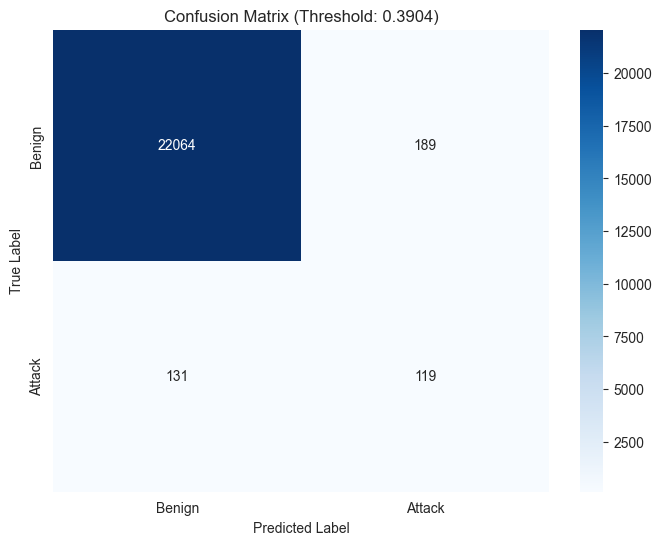

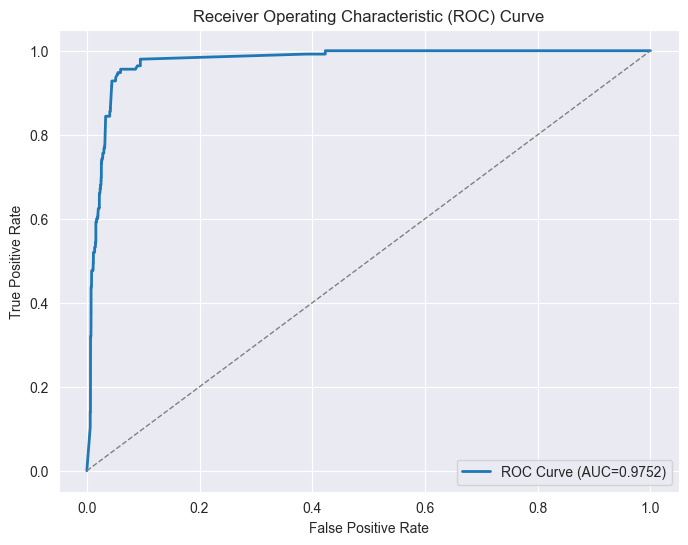


[Test Evaluation]
Processed 142/142 test graphs that contained labels.
Test Set Class Distribution: {np.int64(0): np.int64(22253), np.int64(1): np.int64(250)}

Model AUC: 0.9752
Calculated Optimal Threshold: 0.390420
Precision=0.3864, Recall=0.4760, F1=0.4265, Accuracy=0.9858

Confusion Matrix:
[[22064   189]
 [  131   119]]


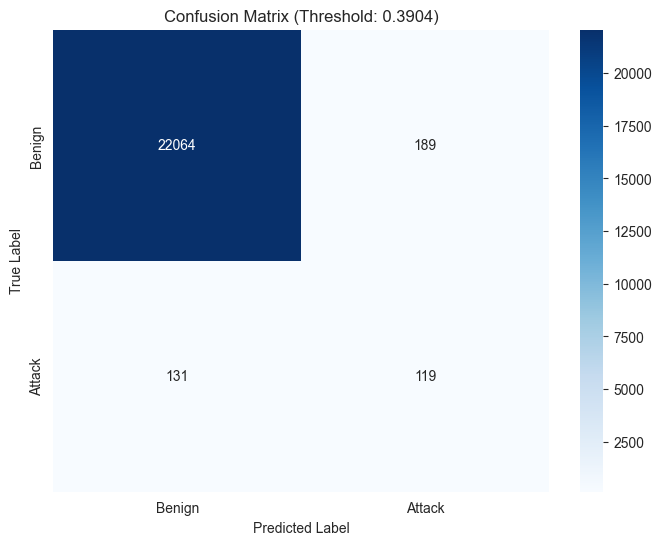

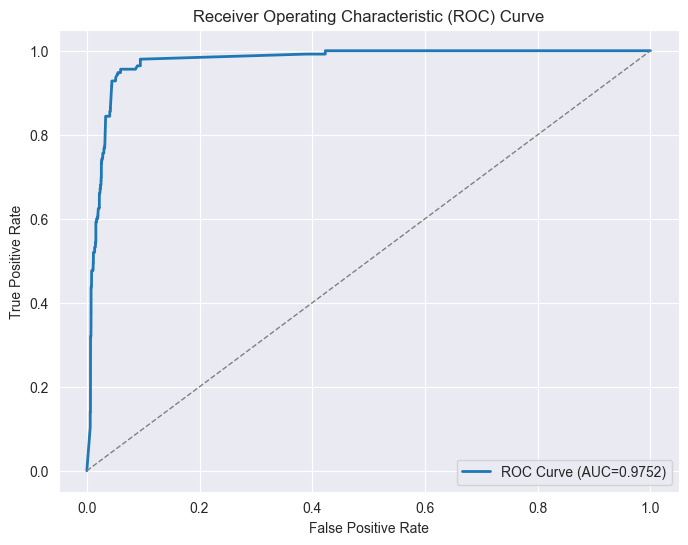

Metrics for 'CONFIG A' saved successfully to model_metrics.json.


In [56]:
# CONFIG A

if __name__ == "__main__":
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Using device: {device}")

    features_to_keep = network_features + required_columns
    active_edges = {'network'}

    train_dir = "CONFIG_A/CONFIG_A_3ed_trai_h_graphs_hetero_graphs"
    train_files = [f for f in os.listdir(train_dir) if f.endswith('.pt')]
    train_graphs = [load_single_graph(train_dir, f) for f in train_files]

    print(f"Loaded {len(train_graphs)} training graphs.")

    hidden_channels = 64
    out_channels = 32
    
    # Initialize the model dynamically passing the 'active_edges' set
    model = HeteroEdgeClassifier(active_edges, hidden_channels, out_channels)

    train_edge_classifier(model, train_graphs, epochs=50, device=device, alpha=0.75, gamma=2.0)

    test_dir = "CONFIG_A/CONFIG_A_3ed_tes_h_graphs_hetero_graphs"
    test_files = [f for f in os.listdir(test_dir) if f.endswith('.pt')]
    test_graphs = [load_single_graph(test_dir, f) for f in test_files]

    print(f"Loaded {len(test_graphs)} test graph(s).")

    # Evaluate using dynamic optimal thresholding
    evaluate_edge_classifier(model, test_graphs, device=device)
    
    # Evaluate using dynamic optimal thresholding
    metrics = evaluate_edge_classifier(model, test_graphs, device=device)
    
    # Save the metrics for this configuration
    save_metrics("CONFIG A", metrics)

Using device: cpu
Loaded 148 training graphs.
[DEBUG] Out of 148 training graphs, only 148 had labels.
[DEBUG] Training Class Distribution -> Benign (0): 165324, Attack (1): 644
[Epoch 1/50] Loss: 0.0573
[Epoch 2/50] Loss: 0.0412
[Epoch 3/50] Loss: 0.0387
[Epoch 4/50] Loss: 0.0384
[Epoch 5/50] Loss: 0.0376
[Epoch 6/50] Loss: 0.0359
[Epoch 7/50] Loss: 0.0368
[Epoch 8/50] Loss: 0.0365
[Epoch 9/50] Loss: 0.0361
[Epoch 10/50] Loss: 0.0367
[Epoch 11/50] Loss: 0.0358
[Epoch 12/50] Loss: 0.0357
[Epoch 13/50] Loss: 0.0363
[Epoch 14/50] Loss: 0.0349
[Epoch 15/50] Loss: 0.0346
[Epoch 16/50] Loss: 0.0343
[Epoch 17/50] Loss: 0.0345
[Epoch 18/50] Loss: 0.0349
[Epoch 19/50] Loss: 0.0342
[Epoch 20/50] Loss: 0.0352
[Epoch 21/50] Loss: 0.0343
[Epoch 22/50] Loss: 0.0346
[Epoch 23/50] Loss: 0.0340
[Epoch 24/50] Loss: 0.0337
[Epoch 25/50] Loss: 0.0350
[Epoch 26/50] Loss: 0.0341
[Epoch 27/50] Loss: 0.0345
[Epoch 28/50] Loss: 0.0342
[Epoch 29/50] Loss: 0.0335
[Epoch 30/50] Loss: 0.0340
[Epoch 31/50] Loss: 0

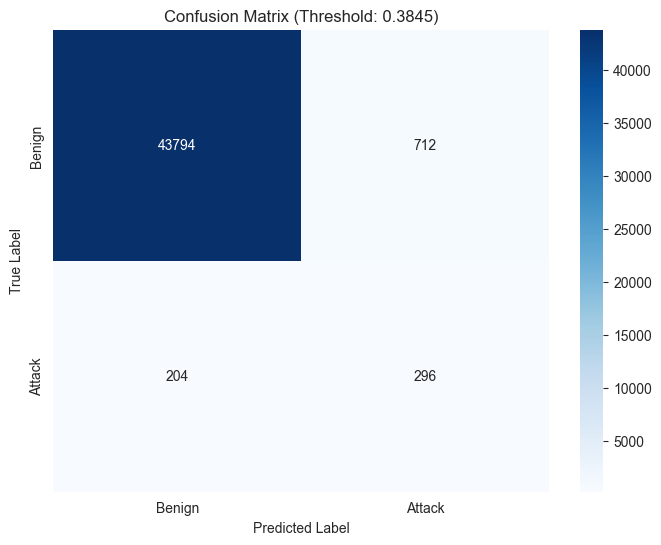

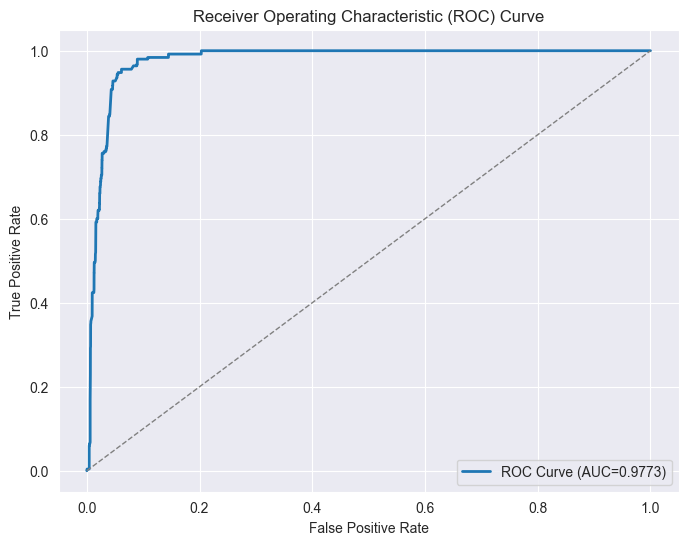


[Test Evaluation]
Processed 142/142 test graphs that contained labels.
Test Set Class Distribution: {np.int64(0): np.int64(44506), np.int64(1): np.int64(500)}

Model AUC: 0.9773
Calculated Optimal Threshold: 0.384513
Precision=0.2937, Recall=0.5920, F1=0.3926, Accuracy=0.9796

Confusion Matrix:
[[43794   712]
 [  204   296]]


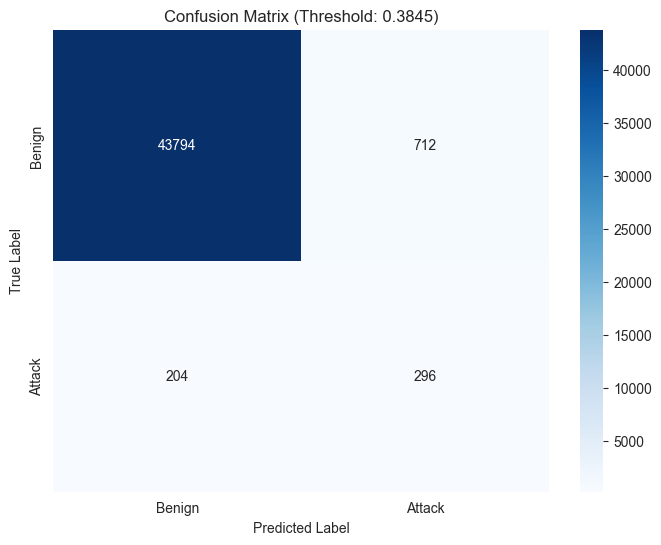

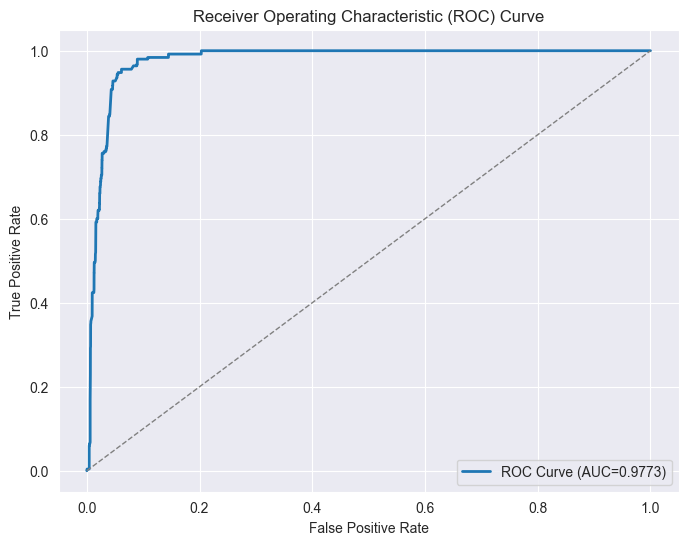

Metrics for 'CONFIG B' saved successfully to model_metrics.json.


In [57]:
# CONFIG B

if __name__ == "__main__":
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Using device: {device}")

    features_to_keep = network_features + context_features + required_columns
    active_edges = {'network', 'context'}

    train_dir = "CONFIG_B/CONFIG_B_3ed_trai_h_graphs_hetero_graphs"
    train_files = [f for f in os.listdir(train_dir) if f.endswith('.pt')]
    train_graphs = [load_single_graph(train_dir, f) for f in train_files]

    print(f"Loaded {len(train_graphs)} training graphs.")

    hidden_channels = 64
    out_channels = 32
    
    # Initialize the model dynamically passing the 'active_edges' set
    model = HeteroEdgeClassifier(active_edges, hidden_channels, out_channels)

    train_edge_classifier(model, train_graphs, epochs=50, device=device, alpha=0.9, gamma=2.0)

    test_dir = "CONFIG_B/CONFIG_B_3ed_tes_h_graphs_hetero_graphs"
    test_files = [f for f in os.listdir(test_dir) if f.endswith('.pt')]
    test_graphs = [load_single_graph(test_dir, f) for f in test_files]

    print(f"Loaded {len(test_graphs)} test graph(s).")

    # Evaluate using dynamic optimal thresholding
    evaluate_edge_classifier(model, test_graphs, device=device)
    
    # Evaluate using dynamic optimal thresholding
    metrics = evaluate_edge_classifier(model, test_graphs, device=device)
    
    # Save the metrics for this configuration
    save_metrics("CONFIG B", metrics)

Using device: cpu
Loaded 148 training graphs.
[DEBUG] Out of 148 training graphs, only 148 had labels.
[DEBUG] Training Class Distribution -> Benign (0): 165324, Attack (1): 644
[Epoch 1/50] Loss: 0.0897
[Epoch 2/50] Loss: 0.0441
[Epoch 3/50] Loss: 0.0428
[Epoch 4/50] Loss: 0.0389
[Epoch 5/50] Loss: 0.0395
[Epoch 6/50] Loss: 0.0378
[Epoch 7/50] Loss: 0.0376
[Epoch 8/50] Loss: 0.0368
[Epoch 9/50] Loss: 0.0349
[Epoch 10/50] Loss: 0.0367
[Epoch 11/50] Loss: 0.0369
[Epoch 12/50] Loss: 0.0346
[Epoch 13/50] Loss: 0.0356
[Epoch 14/50] Loss: 0.0338
[Epoch 15/50] Loss: 0.0361
[Epoch 16/50] Loss: 0.0345
[Epoch 17/50] Loss: 0.0349
[Epoch 18/50] Loss: 0.0346
[Epoch 19/50] Loss: 0.0349
[Epoch 20/50] Loss: 0.0341
[Epoch 21/50] Loss: 0.0344
[Epoch 22/50] Loss: 0.0343
[Epoch 23/50] Loss: 0.0336
[Epoch 24/50] Loss: 0.0348
[Epoch 25/50] Loss: 0.0350
[Epoch 26/50] Loss: 0.0342
[Epoch 27/50] Loss: 0.0343
[Epoch 28/50] Loss: 0.0336
[Epoch 29/50] Loss: 0.0346
[Epoch 30/50] Loss: 0.0348
[Epoch 31/50] Loss: 0

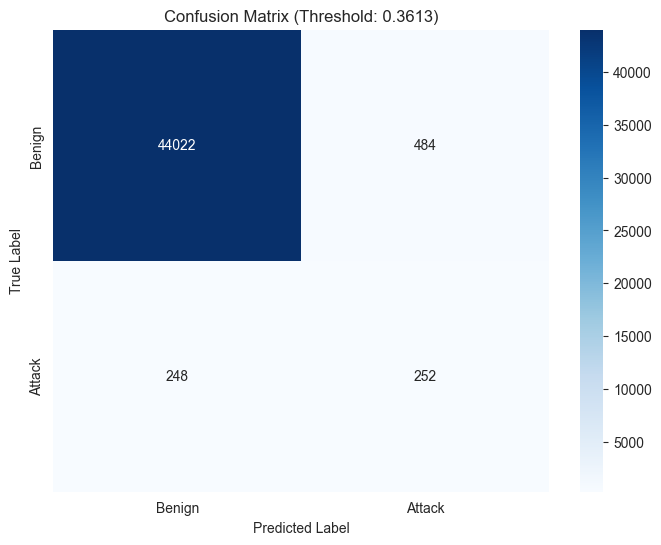

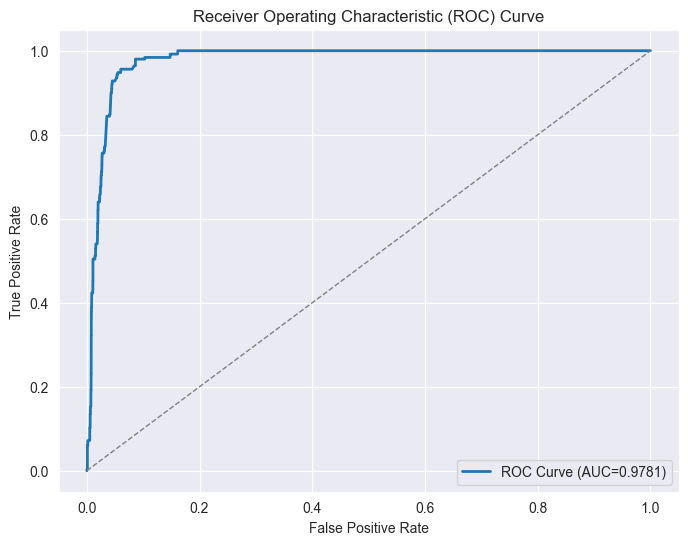


[Test Evaluation]
Processed 142/142 test graphs that contained labels.
Test Set Class Distribution: {np.int64(0): np.int64(44506), np.int64(1): np.int64(500)}

Model AUC: 0.9781
Calculated Optimal Threshold: 0.361329
Precision=0.3424, Recall=0.5040, F1=0.4078, Accuracy=0.9837

Confusion Matrix:
[[44022   484]
 [  248   252]]


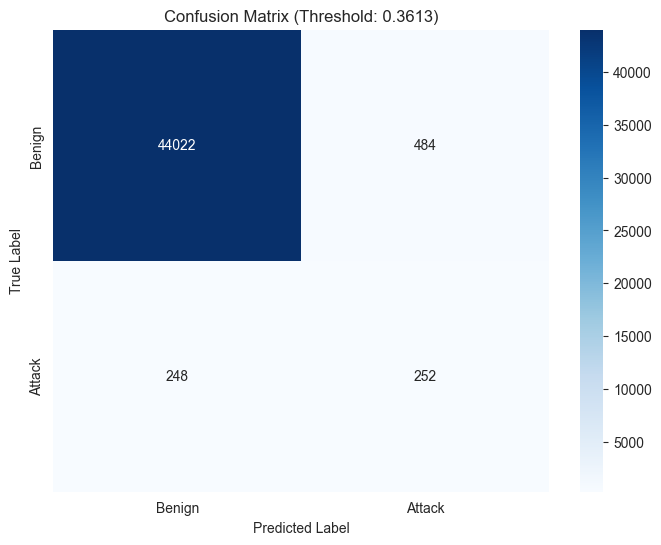

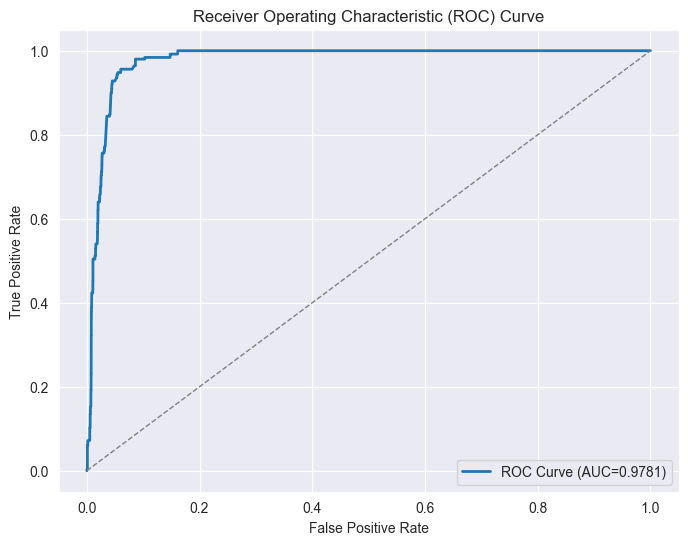

Metrics for 'CONFIG C' saved successfully to model_metrics.json.


In [58]:
# CONFIG C

if __name__ == "__main__":
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Using device: {device}")

    features_to_keep = network_features + knowledge_features + required_columns
    active_edges = {'network', 'knowledge'}

    train_dir = "CONFIG_C/CONFIG_C_3ed_trai_h_graphs_hetero_graphs"
    train_files = [f for f in os.listdir(train_dir) if f.endswith('.pt')]
    train_graphs = [load_single_graph(train_dir, f) for f in train_files]

    print(f"Loaded {len(train_graphs)} training graphs.")

    hidden_channels = 64
    out_channels = 32
    
    # Initialize the model dynamically passing the 'active_edges' set
    model = HeteroEdgeClassifier(active_edges, hidden_channels, out_channels)

    train_edge_classifier(model, train_graphs, epochs=50, device=device, alpha=0.9, gamma=2.0)

    test_dir = "CONFIG_C/CONFIG_C_3ed_tes_h_graphs_hetero_graphs"
    test_files = [f for f in os.listdir(test_dir) if f.endswith('.pt')]
    test_graphs = [load_single_graph(test_dir, f) for f in test_files]

    print(f"Loaded {len(test_graphs)} test graph(s).")

    # Evaluate using dynamic optimal thresholding
    evaluate_edge_classifier(model, test_graphs, device=device)
    
    # Evaluate using dynamic optimal thresholding
    metrics = evaluate_edge_classifier(model, test_graphs, device=device)
    
    # Save the metrics for this configuration
    save_metrics("CONFIG C", metrics)

Using device: cpu
Loaded 148 training graphs.
[DEBUG] Out of 148 training graphs, only 148 had labels.
[DEBUG] Training Class Distribution -> Benign (0): 247986, Attack (1): 966
[Epoch 1/50] Loss: 0.0836
[Epoch 2/50] Loss: 0.0509
[Epoch 3/50] Loss: 0.0501
[Epoch 4/50] Loss: 0.0468
[Epoch 5/50] Loss: 0.0476
[Epoch 6/50] Loss: 0.0469
[Epoch 7/50] Loss: 0.0463
[Epoch 8/50] Loss: 0.0463
[Epoch 9/50] Loss: 0.0438
[Epoch 10/50] Loss: 0.0452
[Epoch 11/50] Loss: 0.0451
[Epoch 12/50] Loss: 0.0445
[Epoch 13/50] Loss: 0.0447
[Epoch 14/50] Loss: 0.0434
[Epoch 15/50] Loss: 0.0430
[Epoch 16/50] Loss: 0.0434
[Epoch 17/50] Loss: 0.0434
[Epoch 18/50] Loss: 0.0428
[Epoch 19/50] Loss: 0.0447
[Epoch 20/50] Loss: 0.0424
[Epoch 21/50] Loss: 0.0432
[Epoch 22/50] Loss: 0.0428
[Epoch 23/50] Loss: 0.0434
[Epoch 24/50] Loss: 0.0426
[Epoch 25/50] Loss: 0.0424
[Epoch 26/50] Loss: 0.0430
[Epoch 27/50] Loss: 0.0427
[Epoch 28/50] Loss: 0.0424
[Epoch 29/50] Loss: 0.0421
[Epoch 30/50] Loss: 0.0420
[Epoch 31/50] Loss: 0

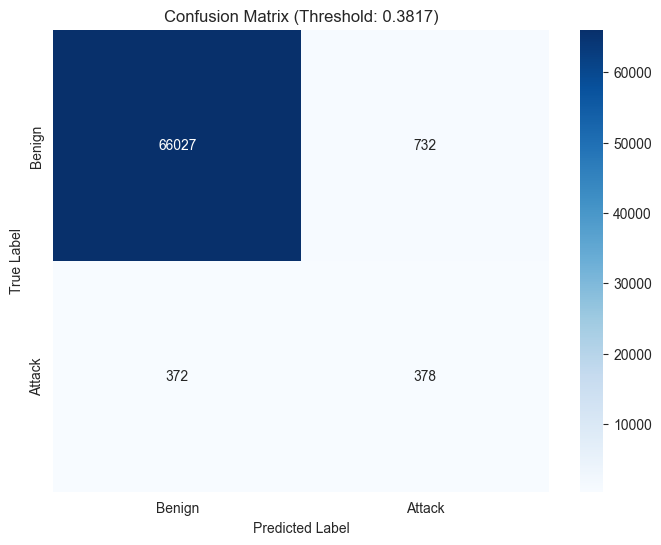

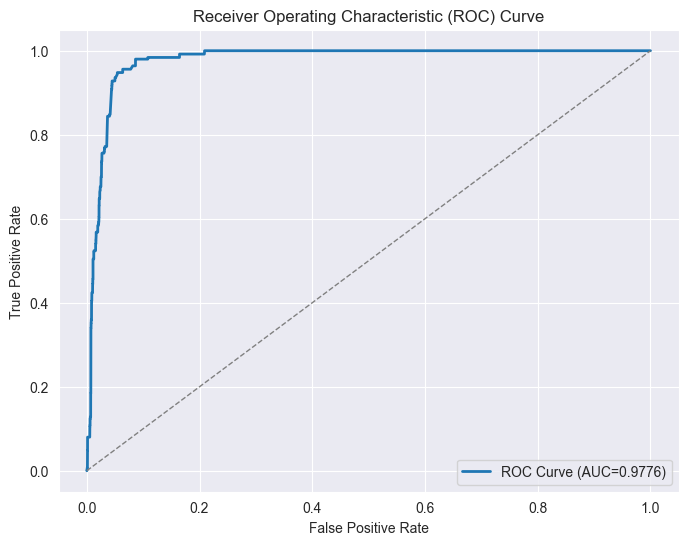


[Test Evaluation]
Processed 142/142 test graphs that contained labels.
Test Set Class Distribution: {np.int64(0): np.int64(66759), np.int64(1): np.int64(750)}

Model AUC: 0.9776
Calculated Optimal Threshold: 0.381737
Precision=0.3405, Recall=0.5040, F1=0.4065, Accuracy=0.9836

Confusion Matrix:
[[66027   732]
 [  372   378]]


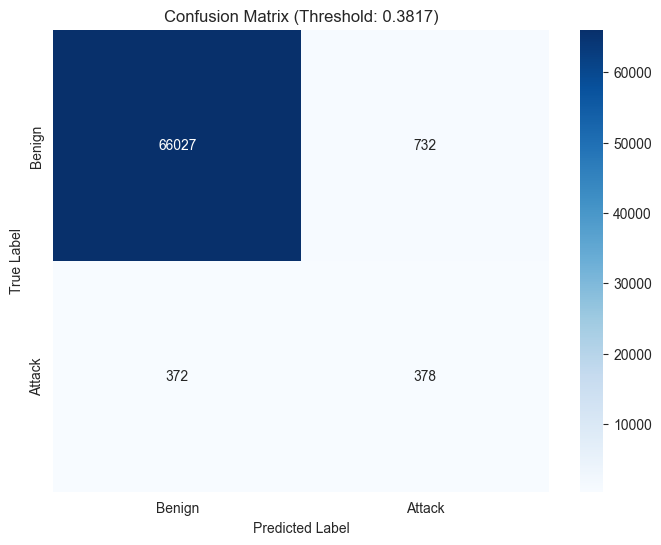

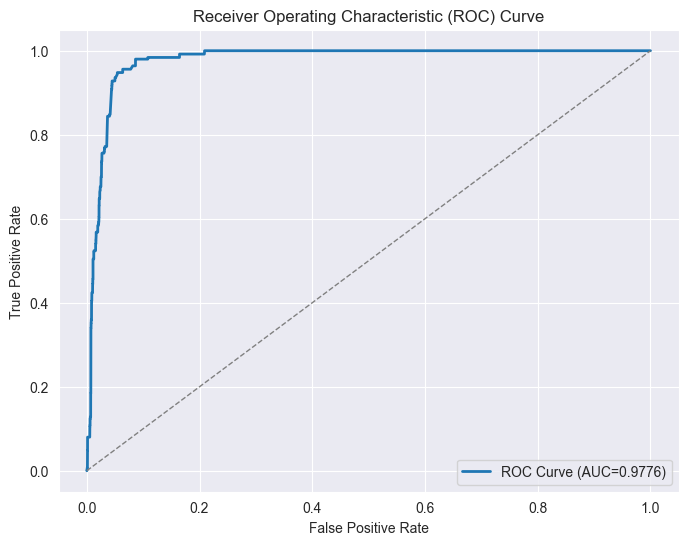

Metrics for 'CONFIG D' saved successfully to model_metrics.json.


In [59]:
# CONFIG D

if __name__ == "__main__":
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Using device: {device}")

    features_to_keep = network_features + context_features + knowledge_features + required_columns
    active_edges = {'network', 'context', 'knowledge'}

    train_dir = "CONFIG_D/CONFIG_D_3ed_trai_h_graphs_hetero_graphs"
    train_files = [f for f in os.listdir(train_dir) if f.endswith('.pt')]
    train_graphs = [load_single_graph(train_dir, f) for f in train_files]

    print(f"Loaded {len(train_graphs)} training graphs.")

    hidden_channels = 64
    out_channels = 32
    
    # Initialize the model dynamically passing the 'active_edges' set
    model = HeteroEdgeClassifier(active_edges, hidden_channels, out_channels)

    train_edge_classifier(model, train_graphs, epochs=50, device=device, alpha=0.75, gamma=2.0)

    test_dir = "CONFIG_D/CONFIG_D_3ed_tes_h_graphs_hetero_graphs"
    test_files = [f for f in os.listdir(test_dir) if f.endswith('.pt')]
    test_graphs = [load_single_graph(test_dir, f) for f in test_files]

    print(f"Loaded {len(test_graphs)} test graph(s).")

    # Evaluate using dynamic optimal thresholding
    evaluate_edge_classifier(model, test_graphs, device=device)
    
    # Evaluate using dynamic optimal thresholding
    metrics = evaluate_edge_classifier(model, test_graphs, device=device)
    
    # Save the metrics for this configuration
    save_metrics("CONFIG D", metrics)

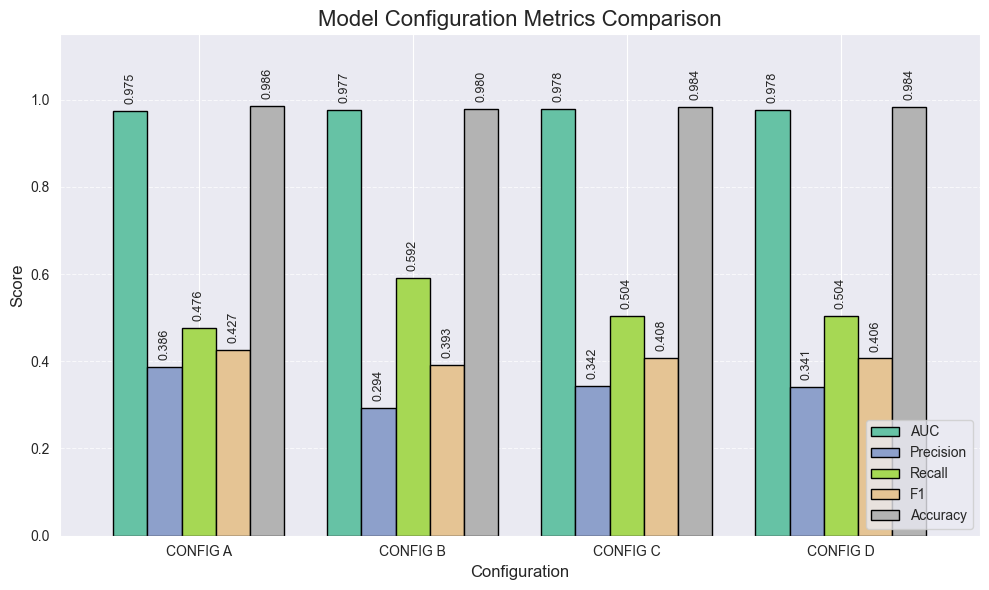

In [60]:
visualize_metrics_comparison()

1. High-Confidence Winner: CONFIG_A
Config A achieved the highest Precision (38.6%) and the highest overall F1-score (42.6%), along with the highest raw accuracy. This means that when Config A flags an edge as an "attack," it is the most likely to be correct compared to the other models. However, this comes at a cost: it misses more actual attacks than the others (lowest Recall at 47.6%).

2. High-Sensitivity Winner: CONFIG_B
Config B is completely flipped. It has a significantly higher Recall (59.2%), meaning it successfully identifies almost 60% of all actual attacks in the graph. But it does this by being much more aggressive in its predictions, which results in the lowest Precision (29.3%). It generates a lot more False Positives.

3. Balanced Middle Ground: CONFIG_C & CONFIG_D
Configs C and D perform almost identically to one another. They offer a compromise between A and B. Interestingly, Config C achieved the highest overall AUC (97.8%), indicating that regardless of the exact threshold chosen, its underlying predicted probabilities separate the Benign and Attack classes better than the other configurations.

Conclusion: Which is best?
Choose CONFIG_A if you have limited resources for investigating alerts and need your model's warnings to be highly accurate (low false positive rate).

Choose CONFIG_B if it is absolutely critical to catch as many attacks as possible, and you don't mind sifting through a higher volume of false alarms.

Choose CONFIG_C if you want the best underlying mathematical separation of the classes (AUC) and a moderate balance between Precision and Recall.

### 1. The Baseline: Configuration A (Network Only)

* **The Results:** Highest Precision (38.6%) and highest F1-score (42.6%), but lowest Recall (47.6%).
* **Commentary:** Using only network traffic as edges creates a highly conservative model. It is very confident when it flags an anomaly (fewest false positives), but it misses more than half of the actual attacks. This proves that relying solely on standard network topology in IoT is insufficient for comprehensive threat detection.

### 2. The Impact of Context: Configuration B (Network + Context)

* **The Results:** Massive jump in Recall (59.2%), but a sharp drop in Precision (29.3%).
* **Commentary:** Adding Context edges radically changes the model's behavior. It becomes highly sensitive, catching significantly more hidden or sophisticated attacks that standard network features missed. However, "Context" seems to introduce noise or overlap with benign behavior, leading to more false alarms. This directly answers your research question: **Context edges act as a sensitivity multiplier.**

### 3. The Impact of Knowledge: Configuration C (Network + Knowledge)

* **The Results:** Highest overall AUC (97.81%) and a balanced profile (Precision 34.2%, Recall 50.4%).
* **Commentary:** Introducing Knowledge edges instead of Context provides the best mathematical separation of classes (AUC). "Knowledge" seems to add highly structured, relevant relational data that improves the graph's overall topology without introducing as much noise as "Context." It strikes a great balance.

### 4. The Full Graph: Configuration D (Network + Context + Knowledge)

* **The Results:** Nearly identical to Config C (AUC 97.76%, Precision 34.0%, Recall 50.4%).
* **Commentary:** This is perhaps the most interesting finding of your ablation study. Combining *all* edge types does not strictly yield the "best" model. The performance plateaus and closely mirrors Configuration C. This suggests that the information provided by "Knowledge" edges might supersede or overlap with the information in "Context" edges. It proves that simply throwing more relationships at a HeteroGNN doesn't guarantee better performance.

### Final Conclusion

1. **Edge types dictate the operational profile:** We can tune the system to be a high-confidence alert system (Network Only) or a high-sensitivity net (Network + Context) simply by changing the graph representation.
2. **More is not always better:** Configuration C (Network + Knowledge) provides the best structural foundation (AUC), and adding Context on top of it (Config D) creates redundancy rather than improvement.